# Rotated NIRCam outflow-region cutouts

This notebook plots each DS9 box in `analysis/outflow_forplotting.reg` with its long axis horizontal. It overlays Gaussian-smoothed H$_2$ continuum-subtraction contours and saves single-column PDF figures. Run the cells from top to bottom.

In [7]:
from pathlib import Path
import re

import astropy.units as u
import colorcet as cc
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import SkyCoord
from astropy.io import fits
from astropy.visualization import AsinhStretch, ImageNormalize
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
from matplotlib.image import imread
from PIL import Image
from scipy.ndimage import gaussian_filter, map_coordinates

## Settings

These are the main values to modify. Leave `PADDING` at 1.0 when the displayed RA/Dec range should be exactly the selected DS9 region.

In [8]:
# Paths
HERE = Path.cwd().resolve()
if not (HERE / 'analysis').exists():
    HERE = HERE.parent

REGION_FILE = HERE / 'analysis' / 'outflow_forplotting.reg'
JWST_DIR = Path(
    '/Users/abarnes/Library/CloudStorage/Dropbox/Data/Galactic/JWST/cloud_h/'
    'jwst/fits/nanfilled/reprojected'
)
NIRCAM_JPEG = JWST_DIR / 'nircam_photoshop.jpeg'
NIRCAM_FITS = (
    JWST_DIR / 'jw07230-o004_t003_nircam_clear-f356w_i2d_nanfilled_reprojected.fits'
)
H2_FITS = Path(
    '/Users/abarnes/Library/CloudStorage/Dropbox/Data/Galactic/JWST/cloud_h/'
    'jwst/fits/nanfilled/H2_F470N_minus_F480M_contsub_nanfilled.fits'
)
OUTPUT_DIR = HERE / 'plots'

# Plot appearance
PADDING = 1.0
FIGURE_WIDTH_INCHES = 3.4
H2_LEVELS = [0.1]
H2_SMOOTHING_SIGMA_PIXELS = 5
H2_CONTOUR_COLOR = 'red'

OUTPUT_DIR.mkdir(exist_ok=True)

## Load the images, WCS information, and DS9 boxes

In [9]:
# JPEG row 0 is at the top, whereas FITS/WCS y=0 is at the bottom.
Image.MAX_IMAGE_PIXELS = None
nircam_rgb = np.flipud(imread(NIRCAM_JPEG)[..., :3])

with fits.open(NIRCAM_FITS, memmap=True) as hdul:
    nircam_shape = hdul[1].data.shape
    nircam_wcs = WCS(hdul[1].header).celestial

with fits.open(H2_FITS, memmap=True) as hdul:
    h2_wcs = WCS(hdul[0].header).celestial

if nircam_rgb.shape[:2] != nircam_shape:
    raise ValueError(
        f'NIRCam JPEG shape {nircam_rgb.shape[:2]} does not match FITS shape {nircam_shape}.'
    )

nircam_pixel_scale = (
    np.mean(proj_plane_pixel_scales(nircam_wcs)) * u.deg
).to_value(u.arcsec)

region_lines = [
    line.strip() for line in REGION_FILE.read_text().splitlines() if line.startswith('box(')
]

print(f'Found {len(region_lines)} DS9 regions.')
print(f'NIRCam pixel scale: {nircam_pixel_scale:.4f} arcsec/pixel')

Found 5 DS9 regions.
NIRCam pixel scale: 0.0310 arcsec/pixel


Set DATE-AVG to '2026-05-12T02:20:38.473' from MJD-AVG.
Set DATE-END to '2026-05-12T02:31:06.605' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -29.337902 from OBSGEO-[XYZ].
Set OBSGEO-H to 1674445997.841 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2026-05-12T01:02:15.728' from MJD-AVG.
Set DATE-END to '2026-05-12T01:20:47.025' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -29.317585 from OBSGEO-[XYZ].
Set OBSGEO-H to 1674214107.139 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


## Make the rotated NIRCam cutouts

The box is the exact image boundary, so no dashed DS9 outline is drawn. The grid and tick marks remain visible, while coordinate labels are hidden.

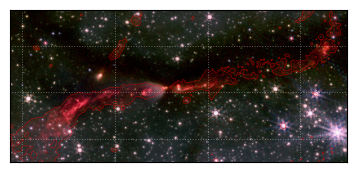

Saved /Users/abarnes/Library/CloudStorage/Dropbox/GitHub/cloudh_outflows/plots/nircam_outflow_region_01.pdf


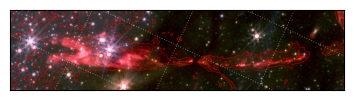

Saved /Users/abarnes/Library/CloudStorage/Dropbox/GitHub/cloudh_outflows/plots/nircam_outflow_region_02.pdf


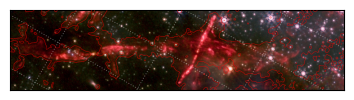

Saved /Users/abarnes/Library/CloudStorage/Dropbox/GitHub/cloudh_outflows/plots/nircam_outflow_region_03.pdf


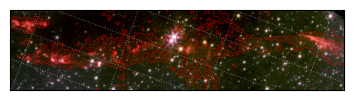

Saved /Users/abarnes/Library/CloudStorage/Dropbox/GitHub/cloudh_outflows/plots/nircam_outflow_region_04.pdf


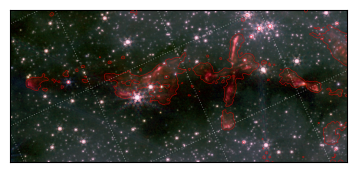

Saved /Users/abarnes/Library/CloudStorage/Dropbox/GitHub/cloudh_outflows/plots/nircam_outflow_region_05.pdf


In [10]:
for region_number, line in enumerate(region_lines, start=1):
    # The region file contains FK5 boxes: RA, Dec, width, height, angle.
    values = re.search(r'box\(([^)]+)\)', line).group(1).split(',')
    ra_deg = float(values[0])
    dec_deg = float(values[1])
    width_arcsec = float(values[2].replace(chr(34), ''))
    height_arcsec = float(values[3].replace(chr(34), ''))
    box_angle_deg = float(values[4])

    # Choose the longer DS9 box side as the new horizontal axis.
    if width_arcsec >= height_arcsec:
        long_axis_arcsec = width_arcsec
        short_axis_arcsec = height_arcsec
        long_axis_pa_deg = box_angle_deg + 90
    else:
        long_axis_arcsec = height_arcsec
        short_axis_arcsec = width_arcsec
        long_axis_pa_deg = box_angle_deg

    output_width = int(np.ceil(PADDING * long_axis_arcsec / nircam_pixel_scale))
    output_height = int(np.ceil(PADDING * short_axis_arcsec / nircam_pixel_scale))
    region_center = SkyCoord(ra_deg * u.deg, dec_deg * u.deg, frame='fk5')

    # Make an output WCS whose positive x axis follows the long box axis.
    wcs_rotation_rad = np.deg2rad(long_axis_pa_deg + 90)
    rotation_matrix = np.array([
        [np.cos(wcs_rotation_rad), -np.sin(wcs_rotation_rad)],
        [np.sin(wcs_rotation_rad), np.cos(wcs_rotation_rad)],
    ])
    cutout_wcs = WCS(naxis=2)
    cutout_wcs.wcs.ctype = ['RA---TAN', 'DEC--TAN']
    cutout_wcs.wcs.cunit = ['deg', 'deg']
    cutout_wcs.wcs.crval = [region_center.ra.deg, region_center.dec.deg]
    cutout_wcs.wcs.crpix = [(output_width + 1) / 2, (output_height + 1) / 2]
    cutout_wcs.wcs.cdelt = [nircam_pixel_scale / 3600, nircam_pixel_scale / 3600]
    cutout_wcs.wcs.pc = np.array([[-1, 0], [0, 1]]) @ rotation_matrix
    cutout_wcs.wcs.set()

    cutout_y, cutout_x = np.mgrid[0:output_height, 0:output_width]
    ra, dec = cutout_wcs.pixel_to_world_values(cutout_x, cutout_y)
    nircam_x, nircam_y = nircam_wcs.world_to_pixel_values(ra, dec)
    h2_x, h2_y = h2_wcs.world_to_pixel_values(ra, dec)

    cutout_rgb = np.empty((output_height, output_width, 3), dtype=nircam_rgb.dtype)
    for channel in range(3):
        cutout_rgb[..., channel] = map_coordinates(
            nircam_rgb[..., channel], [nircam_y, nircam_x], order=1, mode='constant', cval=0
        )

    # Reproject and smooth only this small H2 cutout.
    with fits.open(H2_FITS, memmap=True) as hdul:
        h2_cutout = map_coordinates(
            hdul[0].data, [h2_y, h2_x], order=1, mode='constant', cval=np.nan
        ).astype(np.float32)
    h2_valid = np.isfinite(h2_cutout)
    h2_smoothed_numerator = gaussian_filter(
        np.where(h2_valid, h2_cutout, 0.0), sigma=H2_SMOOTHING_SIGMA_PIXELS
    )
    h2_smoothed_weight = gaussian_filter(
        h2_valid.astype(np.float32), sigma=H2_SMOOTHING_SIGMA_PIXELS
    )
    h2_smoothed = np.full(h2_cutout.shape, np.nan, dtype=np.float32)
    np.divide(
        h2_smoothed_numerator, h2_smoothed_weight, out=h2_smoothed,
        where=h2_smoothed_weight > 0,
    )

    figure_height_inches = FIGURE_WIDTH_INCHES * output_height / output_width
    fig = plt.figure(figsize=(FIGURE_WIDTH_INCHES, figure_height_inches))
    ax = fig.add_subplot(1, 1, 1, projection=cutout_wcs)
    ax.set_facecolor('black')
    ax.imshow(cutout_rgb, origin='lower')
    ax.contour(
        h2_smoothed, levels=H2_LEVELS, colors=H2_CONTOUR_COLOR,
        linewidths=0.5, origin='lower', alpha=0.5,
    )

    # Keep ticks and a grid, but omit all RA/Dec labels.
    ax.coords.grid(color='white', alpha=0.35, linestyle=':', linewidth=0.7)
    ax.coords[0].set_ticks(color='white')
    ax.coords[1].set_ticks(color='white')
    ax.coords[0].set_ticklabel_visible(False)
    ax.coords[1].set_ticklabel_visible(False)
    ax.coords[0].set_axislabel('')
    ax.coords[1].set_axislabel('')

    fig.tight_layout(pad=0.05)
    output_file = OUTPUT_DIR / f'nircam_outflow_region_{region_number:02d}.pdf'
    fig.savefig(output_file, dpi=300, bbox_inches='tight', pad_inches=0.02)
    plt.show()
    plt.close(fig)
    print(f'Saved {output_file}')

## Two-panel RGB and H$_2$ views

This cell uses the same rotated DS9 grids as above. The left panel shows the RGB image and its smoothed H$_2$ contours. The right panel shows the original continuum-subtracted H$_2$ map, without a colourbar.

Set DATE-AVG to '2026-05-12T01:02:15.728' from MJD-AVG.
Set DATE-END to '2026-05-12T01:20:47.025' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -29.317589 from OBSGEO-[XYZ].
Set OBSGEO-H to 1674214111.642 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


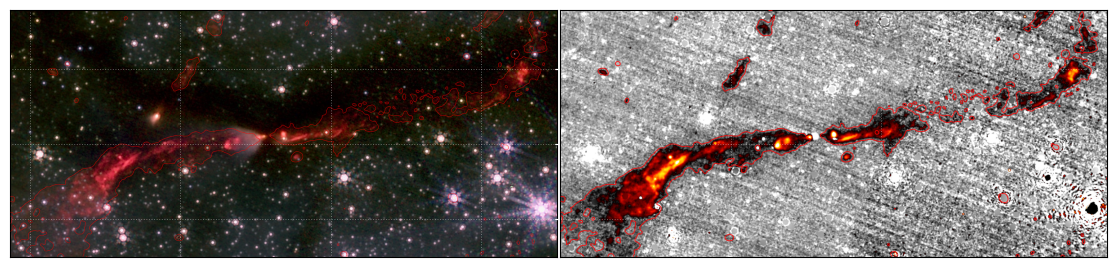

Saved /Users/abarnes/Library/CloudStorage/Dropbox/GitHub/cloudh_outflows/plots/nircam_h2_outflow_region_01.pdf


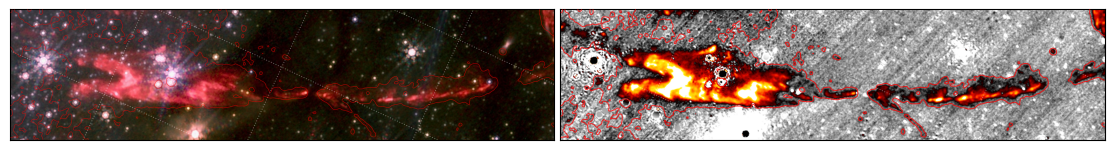

Saved /Users/abarnes/Library/CloudStorage/Dropbox/GitHub/cloudh_outflows/plots/nircam_h2_outflow_region_02.pdf


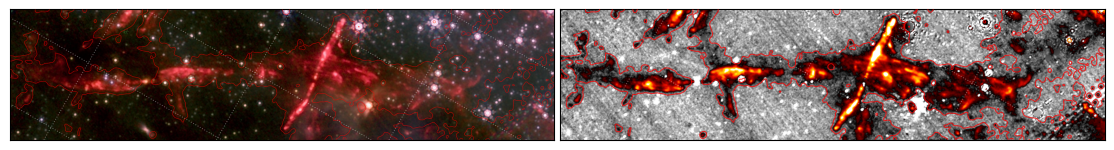

Saved /Users/abarnes/Library/CloudStorage/Dropbox/GitHub/cloudh_outflows/plots/nircam_h2_outflow_region_03.pdf


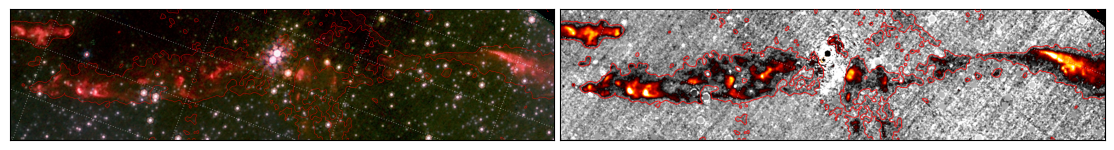

Saved /Users/abarnes/Library/CloudStorage/Dropbox/GitHub/cloudh_outflows/plots/nircam_h2_outflow_region_04.pdf


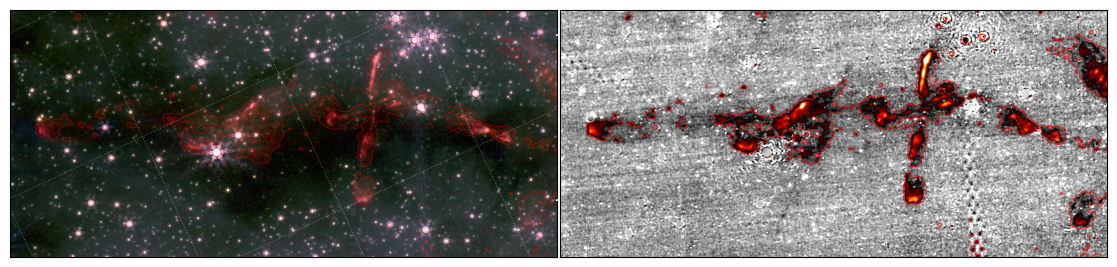

Saved /Users/abarnes/Library/CloudStorage/Dropbox/GitHub/cloudh_outflows/plots/nircam_h2_outflow_region_05.pdf


In [24]:
H2_PANEL_FITS = Path(
    '/Users/abarnes/Library/CloudStorage/Dropbox/Data/Galactic/JWST/cloud_h/'
    'cloud_H_JWST/NIRCam/12-05-2026/contsub/H2_F470N_minus_F480M_contsub.fits'
)
TWO_PANEL_FIGURE_WIDTH_INCHES = 11.0

with fits.open(H2_PANEL_FITS, memmap=True) as hdul:
    h2_panel_image = np.asarray(hdul['SCI'].data, dtype=float)
    h2_panel_wcs = WCS(hdul['SCI'].header).celestial

# The same binary-plus-Colorcet-fire colormap used in plot_miri_ratio_h2_rotated_wcs.ipynb.
binary = plt.get_cmap('binary').resampled(100)
fire = cc.cm.fire.resampled(256)
h2_panel_cmap = mcolors.LinearSegmentedColormap.from_list(
    'binary_fire',
    np.vstack((binary(np.linspace(0, 1, 100)), fire(np.linspace(0, 1, 256)))),
)
h2_panel_cmap.set_bad('black')

for region_number, line in enumerate(region_lines, start=1):
    values = re.search(r'box\(([^)]+)\)', line).group(1).split(',')
    ra_deg = float(values[0])
    dec_deg = float(values[1])
    width_arcsec = float(values[2].replace(chr(34), ''))
    height_arcsec = float(values[3].replace(chr(34), ''))
    box_angle_deg = float(values[4])

    if width_arcsec >= height_arcsec:
        long_axis_arcsec = width_arcsec
        short_axis_arcsec = height_arcsec
        long_axis_pa_deg = box_angle_deg + 90
    else:
        long_axis_arcsec = height_arcsec
        short_axis_arcsec = width_arcsec
        long_axis_pa_deg = box_angle_deg

    output_width = int(np.ceil(PADDING * long_axis_arcsec / nircam_pixel_scale))
    output_height = int(np.ceil(PADDING * short_axis_arcsec / nircam_pixel_scale))
    region_center = SkyCoord(ra_deg * u.deg, dec_deg * u.deg, frame='fk5')

    wcs_rotation_rad = np.deg2rad(long_axis_pa_deg + 90)
    rotation_matrix = np.array([
        [np.cos(wcs_rotation_rad), -np.sin(wcs_rotation_rad)],
        [np.sin(wcs_rotation_rad), np.cos(wcs_rotation_rad)],
    ])
    cutout_wcs = WCS(naxis=2)
    cutout_wcs.wcs.ctype = ['RA---TAN', 'DEC--TAN']
    cutout_wcs.wcs.cunit = ['deg', 'deg']
    cutout_wcs.wcs.crval = [region_center.ra.deg, region_center.dec.deg]
    cutout_wcs.wcs.crpix = [(output_width + 1) / 2, (output_height + 1) / 2]
    cutout_wcs.wcs.cdelt = [nircam_pixel_scale / 3600, nircam_pixel_scale / 3600]
    cutout_wcs.wcs.pc = np.array([[-1, 0], [0, 1]]) @ rotation_matrix
    cutout_wcs.wcs.set()

    cutout_y, cutout_x = np.mgrid[0:output_height, 0:output_width]
    ra, dec = cutout_wcs.pixel_to_world_values(cutout_x, cutout_y)
    nircam_x, nircam_y = nircam_wcs.world_to_pixel_values(ra, dec)
    h2_contour_x, h2_contour_y = h2_wcs.world_to_pixel_values(ra, dec)
    h2_panel_x, h2_panel_y = h2_panel_wcs.world_to_pixel_values(ra, dec)

    cutout_rgb = np.empty((output_height, output_width, 3), dtype=nircam_rgb.dtype)
    for channel in range(3):
        cutout_rgb[..., channel] = map_coordinates(
            nircam_rgb[..., channel], [nircam_y, nircam_x], order=1, mode='constant', cval=0
        )

    with fits.open(H2_FITS, memmap=True) as hdul:
        h2_contour = map_coordinates(
            hdul[0].data, [h2_contour_y, h2_contour_x], order=1, mode='constant', cval=np.nan
        ).astype(np.float32)
    h2_contour_valid = np.isfinite(h2_contour)
    h2_contour_numerator = gaussian_filter(
        np.where(h2_contour_valid, h2_contour, 0.0), sigma=H2_SMOOTHING_SIGMA_PIXELS
    )
    h2_contour_weight = gaussian_filter(
        h2_contour_valid.astype(np.float32), sigma=H2_SMOOTHING_SIGMA_PIXELS
    )
    h2_contour_smoothed = np.full(h2_contour.shape, np.nan, dtype=np.float32)
    np.divide(
        h2_contour_numerator, h2_contour_weight, out=h2_contour_smoothed,
        where=h2_contour_weight > 0,
    )

    h2_panel_cutout = map_coordinates(
        h2_panel_image, [h2_panel_y, h2_panel_x], order=1, mode='constant', cval=np.nan
    )
    h2_panel_valid = np.isfinite(h2_panel_cutout)
    # h2_panel_limits = np.nanpercentile(h2_panel_cutout[h2_panel_valid], [5, 99.9])
    h2_panel_limits = np.array([-0.25,  7])
    h2_panel_norm = ImageNormalize(
        vmin=h2_panel_limits[0], vmax=h2_panel_limits[1],
        stretch=AsinhStretch(0.1), clip=False,
    )

    figure_height_inches = TWO_PANEL_FIGURE_WIDTH_INCHES * output_height / (2 * output_width)
    fig, (ax_rgb, ax_h2) = plt.subplots(
        1, 2, figsize=(TWO_PANEL_FIGURE_WIDTH_INCHES, figure_height_inches),
        subplot_kw={'projection': cutout_wcs},
    )

    ax_rgb.set_facecolor('black')
    ax_rgb.imshow(cutout_rgb, origin='lower')
    ax_rgb.contour(
        h2_contour_smoothed, levels=H2_LEVELS, colors=H2_CONTOUR_COLOR,
        linewidths=0.5, origin='lower', alpha=0.5,
    )
    # ax_rgb.set_title('NIRCam RGB', fontsize=9)

    ax_h2.set_facecolor('black')
    ax_h2.imshow(
        np.ma.masked_invalid(h2_panel_cutout), origin='lower', cmap=h2_panel_cmap, norm=h2_panel_norm
    )
    # ax_h2.set_title(r'H$_2$ F470N $-$ F480M', fontsize=9)

    ax_h2.contour(
        h2_contour_smoothed, levels=H2_LEVELS, colors=H2_CONTOUR_COLOR,
        linewidths=0.75, origin='lower', alpha=0.75,
    )

    for ax in (ax_rgb, ax_h2):
        ax.coords.grid(color='white', alpha=0.35, linestyle=':', linewidth=0.7)
        ax.coords[0].set_ticks(color='white')
        ax.coords[1].set_ticks(color='white')
        ax.coords[0].set_ticklabel_visible(False)
        ax.coords[1].set_ticklabel_visible(False)
        ax.coords[0].set_axislabel('')
        ax.coords[1].set_axislabel('')

    fig.tight_layout(pad=0.05, w_pad=0.15)
    output_file = OUTPUT_DIR / f'nircam_h2_outflow_region_{region_number:02d}.pdf'
    fig.savefig(output_file, dpi=300, bbox_inches='tight', pad_inches=0.02)
    plt.show()
    plt.close(fig)
    print(f'Saved {output_file}')

In [25]:
h2_panel_limits

array([-0.25,  7.  ])